# Poisson CINAR(p) model selection for one NASA day

This notebook performs a leakage-safe, chronological model-selection workflow for one complete 10:00-18:00 NASA HTTP day. It can use either the original `unique_hosts` counts or the integer seasonally adjusted counts created by the EDA notebook.

The workflow is:

1. choose an available date and dataset version;
2. split its 481 observations into contiguous training, validation, and test blocks;
3. inspect the training ACF and PACF and use them to choose candidate orders $p$;
4. fit every selected combination of order $p$ and thinning operator on training data only;
5. rank candidates by recursive validation MSE;
6. refit the selected specification on training plus validation data; and
7. evaluate one untouched recursive forecast on the test block.

Validation and test forecasts use only observations available before their forecast origins. No value from either holdout block is used to update a forecast recursively.

In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

from cinar import PoissonCINARp

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (13, 5), "figure.dpi": 110})

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"

# ---- User choices ---------------------------------------------------------
CHOSEN_DATE = "1995-07-02"
DATASET_KIND = "raw"  # "raw" or "seasonally_adjusted"
THINNING_OPERATORS = ("independent", "identical")
TRAIN_FRACTION = 0.60
VALIDATION_FRACTION = 0.20
ACF_PACF_LAGS = 40
MAX_CANDIDATE_ORDER = 2
# The final fraction is reserved for testing.

print(f"Project directory: {PROJECT_DIR.resolve()}")
print(f"Chosen dataset: {DATASET_KIND}")
print(f"Maximum candidate order considered after diagnostics: {MAX_CANDIDATE_ORDER}")
print(f"Thinning operators: {THINNING_OPERATORS}")

Project directory: /Users/andja/Projects/projekti_doktorske/nasa
Chosen dataset: raw
Maximum candidate order considered after diagnostics: 2
Thinning operators: ('independent', 'identical')


## 1. Load one complete day

`DATASET_KIND = "raw"` uses `unique_hosts`. Setting it to `"seasonally_adjusted"` uses the nonnegative integer `unique_hosts_seasonally_adjusted` column. The adjusted CSV is treated as an already prepared modeling input.

In [2]:
dataset_options = {
    "raw": (
        DATA_DIR / "NASA_HTTP_minute_10_to_18.csv",
        "unique_hosts",
    ),
    "seasonally_adjusted": (
        DATA_DIR / "NASA_HTTP_minute_10_to_18_seasonally_adjusted.csv",
        "unique_hosts_seasonally_adjusted",
    ),
}

dataset_path, response_column = dataset_options[DATASET_KIND]
all_data = pd.read_csv(dataset_path, parse_dates=["minute", "date"])
available_days = all_data["date"].dt.strftime("%Y-%m-%d").drop_duplicates()

day_data = (
    all_data.loc[all_data["date"].dt.strftime("%Y-%m-%d").eq(CHOSEN_DATE)]
    .sort_values("minute_in_window")
    .reset_index(drop=True)
)
counts = day_data[response_column].to_numpy(dtype=np.int64)

print(f"Available complete dates ({len(available_days)}):")
print(", ".join(available_days))
print(f"\nSelected {CHOSEN_DATE}: {len(counts)} observations from {dataset_path.name}")
print(f"Response column: {response_column}")
day_data[["minute", "minute_in_window", response_column]].head()

Available complete dates (36):
1995-07-02, 1995-07-03, 1995-07-04, 1995-07-06, 1995-07-08, 1995-07-09, 1995-07-10, 1995-07-11, 1995-07-12, 1995-07-14, 1995-07-15, 1995-07-16, 1995-07-17, 1995-07-18, 1995-07-19, 1995-07-20, 1995-07-24, 1995-07-25, 1995-07-27, 1995-08-05, 1995-08-06, 1995-08-08, 1995-08-11, 1995-08-12, 1995-08-13, 1995-08-17, 1995-08-19, 1995-08-20, 1995-08-22, 1995-08-23, 1995-08-25, 1995-08-26, 1995-08-27, 1995-08-28, 1995-08-29, 1995-08-30

Selected 1995-07-02: 481 observations from NASA_HTTP_minute_10_to_18.csv
Response column: unique_hosts


,minute,minute_in_window,unique_hosts
0,1995-07-02 10:00:00,1,14
1,1995-07-02 10:01:00,2,11
2,1995-07-02 10:02:00,3,9
3,1995-07-02 10:03:00,4,13
4,1995-07-02 10:04:00,5,8


## 2. Chronological train-validation-test split

The split is contiguous rather than random. This preserves temporal order and prevents future observations from leaking into model fitting. With the default fractions, the first 60% is training data, the next 20% is validation data, and the remaining observations form the test set.

In [3]:
train_end = int(len(counts) * TRAIN_FRACTION)
validation_end = train_end + int(len(counts) * VALIDATION_FRACTION)

train = counts[:train_end]
validation = counts[train_end:validation_end]
test = counts[validation_end:]
development = counts[:validation_end]

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "observations": [len(train), len(validation), len(test)],
        "start": [day_data.loc[0, "minute"], day_data.loc[train_end, "minute"], day_data.loc[validation_end, "minute"]],
        "end": [day_data.loc[train_end - 1, "minute"], day_data.loc[validation_end - 1, "minute"], day_data.loc[len(counts) - 1, "minute"]],
        "mean": [train.mean(), validation.mean(), test.mean()],
        "variance": [train.var(ddof=1), validation.var(ddof=1), test.var(ddof=1)],
    }
)
split_summary

,split,observations,start,end,mean,variance
0,train,288,1995-07-02 10:00:00,1995-07-02 14:47:00,18.121528,22.072288
1,validation,96,1995-07-02 14:48:00,1995-07-02 16:23:00,17.447917,13.323575
2,test,97,1995-07-02 16:24:00,1995-07-02 18:00:00,22.309278,21.403351


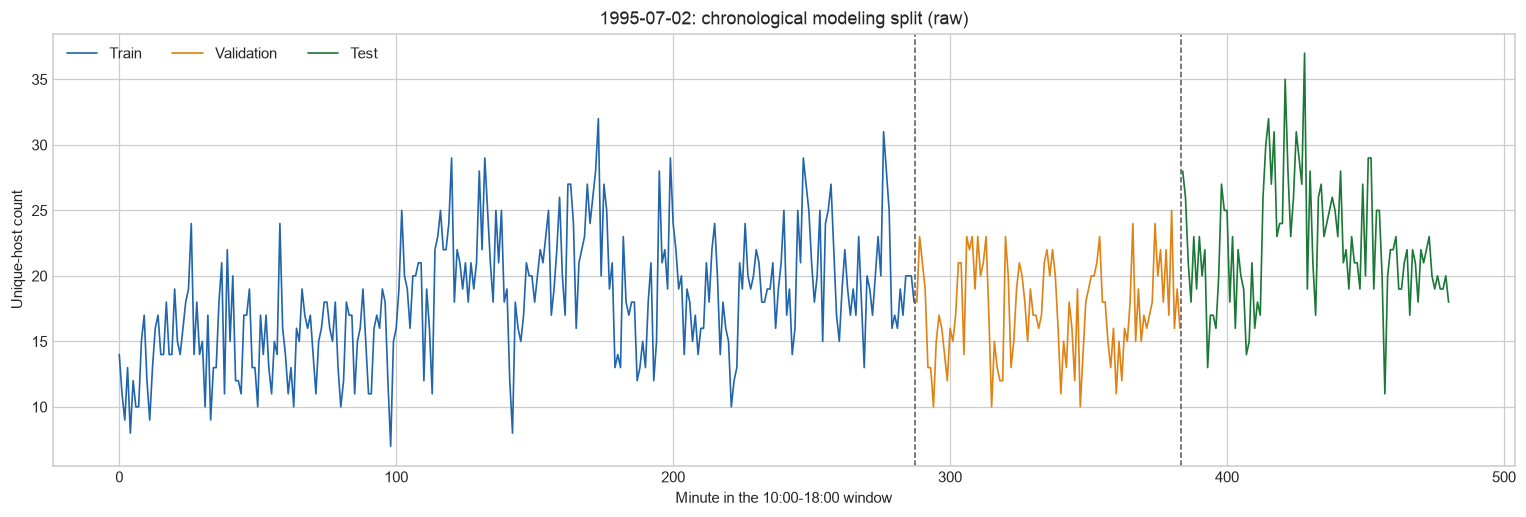

In [4]:
fig, ax = plt.subplots(figsize=(14, 4.8))
time_index = np.arange(len(counts))
ax.plot(time_index[:train_end], train, color="#2166ac", linewidth=1.1, label="Train")
ax.plot(time_index[train_end:validation_end], validation, color="#e08214", linewidth=1.1, label="Validation")
ax.plot(time_index[validation_end:], test, color="#1b7837", linewidth=1.1, label="Test")
ax.axvline(train_end - 0.5, color="#555555", linestyle="--", linewidth=1)
ax.axvline(validation_end - 0.5, color="#555555", linestyle="--", linewidth=1)
ax.set(
    title=f"{CHOSEN_DATE}: chronological modeling split ({DATASET_KIND})",
    xlabel="Minute in the 10:00-18:00 window",
    ylabel="Unique-host count",
)
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

## 3. Diagnose training dependence and choose candidate orders

Only the training block is used for these diagnostics. The ACF shows how dependence decays over successive minute lags, while the PACF highlights lags with direct association after accounting for shorter lags. The dashed confidence bands in the plots are the usual approximate 95% limits.

Candidate orders are chosen from statistically significant PACF lags up to `MAX_CANDIDATE_ORDER`, with $p=1$ always retained as a baseline. This makes the choice reproducible while allowing the computational ceiling to be adjusted in the configuration cell. The exact identical-thinning filter can become expensive at larger orders, so the default ceiling is 2.

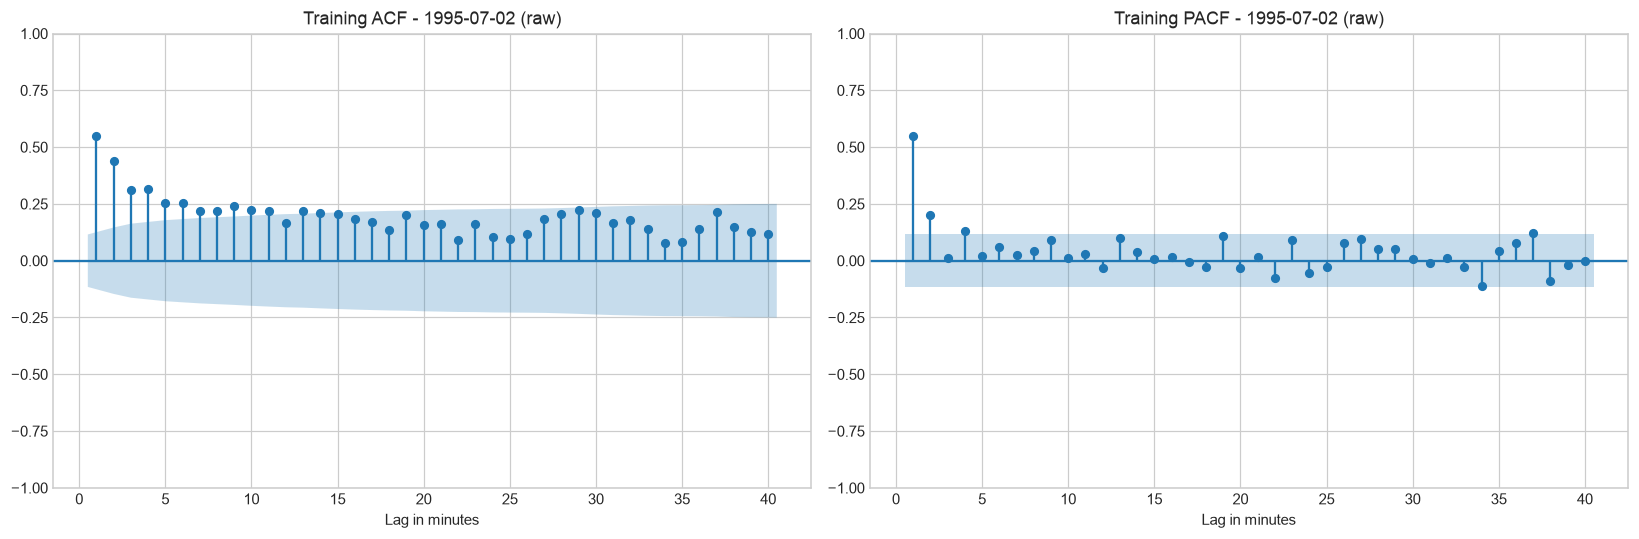

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(train, lags=ACF_PACF_LAGS, alpha=0.05, zero=False, ax=axes[0])
plot_pacf(
    train,
    lags=ACF_PACF_LAGS,
    alpha=0.05,
    zero=False,
    method="ywm",
    ax=axes[1],
)
axes[0].set_title(f"Training ACF - {CHOSEN_DATE} ({DATASET_KIND})")
axes[1].set_title(f"Training PACF - {CHOSEN_DATE} ({DATASET_KIND})")
for axis in axes:
    axis.set_xlabel("Lag in minutes")
fig.tight_layout()
plt.show()

In [6]:
acf_values = acf(train, nlags=ACF_PACF_LAGS, fft=False)
pacf_values = pacf(train, nlags=ACF_PACF_LAGS, method="ywm")
approximate_95_percent_bound = 1.96 / np.sqrt(len(train))

lag_diagnostics = pd.DataFrame(
    {
        "lag": np.arange(1, ACF_PACF_LAGS + 1),
        "ACF": acf_values[1:],
        "PACF": pacf_values[1:],
    }
)
lag_diagnostics["ACF_significant"] = lag_diagnostics["ACF"].abs().gt(approximate_95_percent_bound)
lag_diagnostics["PACF_significant"] = lag_diagnostics["PACF"].abs().gt(approximate_95_percent_bound)

significant_pacf_orders = lag_diagnostics.loc[
    lag_diagnostics["PACF_significant"]
    & lag_diagnostics["lag"].le(MAX_CANDIDATE_ORDER),
    "lag",
].astype(int).tolist()
P_VALUES = tuple(sorted({1, *significant_pacf_orders}))

print(f"Approximate 95% significance bound: +/-{approximate_95_percent_bound:.3f}")
print(f"Significant PACF lags up to {MAX_CANDIDATE_ORDER}: {significant_pacf_orders}")
print(f"Candidate CINAR orders selected from training data: {P_VALUES}")
lag_diagnostics.head(ACF_PACF_LAGS).style.format({"ACF": "{:.3f}", "PACF": "{:.3f}"})


Approximate 95% significance bound: +/-0.115
Significant PACF lags up to 2: [1, 2]
Candidate CINAR orders selected from training data: (1, 2)


,lag,ACF,PACF,ACF_significant,PACF_significant
0,1,0.549,0.549,True,True
1,2,0.440,0.199,True,True
2,3,0.312,0.014,True,False
3,4,0.318,0.132,True,True
4,5,0.256,0.019,True,False
5,6,0.255,0.061,True,False
6,7,0.220,0.027,True,False
7,8,0.220,0.041,True,False
8,9,0.243,0.093,True,False
9,10,0.223,0.014,True,False


## 4. Fit candidates and validate out of sample

Every candidate is estimated on `train` only. Its validation score is the MSE of a recursive multi-step forecast over the complete validation block. Training AIC and BIC are retained as diagnostics, but the winner is selected by validation MSE, with training BIC used only as a deterministic tie-breaker.

The candidate orders in `P_VALUES` now come from the training PACF diagnostic above. The identical-thinning likelihood uses an exact latent-state filter and becomes computationally expensive as $p$ and the observed counts increase; adjust `MAX_CANDIDATE_ORDER` in the configuration cell when a broader search is computationally practical.

In [7]:
def forecast_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict[str, float]:
    errors = actual - predicted
    mse = float(np.mean(errors**2))
    return {
        "mse": mse,
        "rmse": float(np.sqrt(mse)),
        "mae": float(np.mean(np.abs(errors))),
    }


candidate_models = {}
validation_forecasts = {}
candidate_rows = []

for p in P_VALUES:
    for operator in THINNING_OPERATORS:
        label = f"CINAR({p}) - {operator}"
        print(f"Fitting {label} ...")
        model = PoissonCINARp(p=p, thinning_operator=operator).fit(train)
        forecast = model.predict(train, n_steps=len(validation))
        scores = forecast_metrics(validation, forecast)

        candidate_models[(p, operator)] = model
        validation_forecasts[(p, operator)] = forecast
        candidate_rows.append(
            {
                "model": label,
                "p": p,
                "thinning_operator": operator,
                "alpha": model.alpha_,
                "innovation_mean": model.innovation_mean_,
                "phi": np.round(model.phi_, 6).tolist(),
                "train_AIC": model.aic_,
                "train_BIC": model.bic_,
                "train_MSE": model.mse_,
                "validation_MSE": scores["mse"],
                "validation_RMSE": scores["rmse"],
                "validation_MAE": scores["mae"],
            }
        )

comparison = (
    pd.DataFrame(candidate_rows)
    .sort_values(["validation_MSE", "train_BIC"], ignore_index=True)
)
comparison.style.format(
    {
        "alpha": "{:.4f}",
        "innovation_mean": "{:.4f}",
        "train_AIC": "{:.2f}",
        "train_BIC": "{:.2f}",
        "train_MSE": "{:.3f}",
        "validation_MSE": "{:.3f}",
        "validation_RMSE": "{:.3f}",
        "validation_MAE": "{:.3f}",
    }
).highlight_min(subset=["validation_MSE"], color="#c7e9c0")

Fitting CINAR(1) - independent ...


Fitting CINAR(1) - identical ...


Fitting CINAR(2) - independent ...


Fitting CINAR(2) - identical ...


,model,p,thinning_operator,alpha,innovation_mean,phi,train_AIC,train_BIC,train_MSE,validation_MSE,validation_RMSE,validation_MAE
0,CINAR(2) - independent,2,independent,0.5480,8.2017,"[0.738167, 0.261833]",1590.54,1601.50,14.847,13.670,3.697,3.063
1,CINAR(1) - independent,1,independent,0.4963,9.1416,[1.0],1602.43,1609.75,15.430,13.681,3.699,3.062
2,CINAR(1) - identical,1,identical,0.4963,9.1416,[1.0],1602.43,1609.75,15.430,13.681,3.699,3.062
3,CINAR(2) - identical,2,identical,0.5099,8.9005,"[0.658771, 0.341229]",1591.06,1602.02,14.949,13.693,3.700,3.066


## 5. Select, refit, and test the best specification

The first row of the ranked table is the selected specification. It is now refitted on the combined training and validation observations. The test block remains untouched until the single final forecast below.

In [9]:
best = comparison.iloc[0]
best_p = int(best["p"])
best_operator = str(best["thinning_operator"])

print(
    f"Selected by validation MSE: CINAR({best_p}) with "
    f"{best_operator} thinnings (validation MSE={best['validation_MSE']:.3f})."
)

final_model = PoissonCINARp(
    p=best_p,
    thinning_operator=best_operator,
).fit(development)
test_forecast = final_model.predict(development, n_steps=len(test))
test_scores = forecast_metrics(test, test_forecast)

final_report = pd.DataFrame(
    [
        {
            "date": CHOSEN_DATE,
            "dataset": DATASET_KIND,
            "selected_model": f"CINAR({best_p}) - {best_operator}",
            "development_observations": len(development),
            "test_observations": len(test),
            "alpha": final_model.alpha_,
            "innovation_mean": final_model.innovation_mean_,
            "phi": np.round(final_model.phi_, 6).tolist(),
            "development_AIC": final_model.aic_,
            "development_BIC": final_model.bic_,
            "test_MSE": test_scores["mse"],
            "test_RMSE": test_scores["rmse"],
            "test_MAE": test_scores["mae"],
        }
    ]
)
final_report.T

Selected by validation MSE: CINAR(2) with independent thinnings (validation MSE=13.670).


,0
date,1995-07-02
dataset,raw
selected_model,CINAR(2) - independent
development_observations,384
test_observations,97
alpha,0.552935
innovation_mean,8.032135
phi,"[0.725652, 0.274348]"
development_AIC,2095.029259
development_BIC,2106.865521


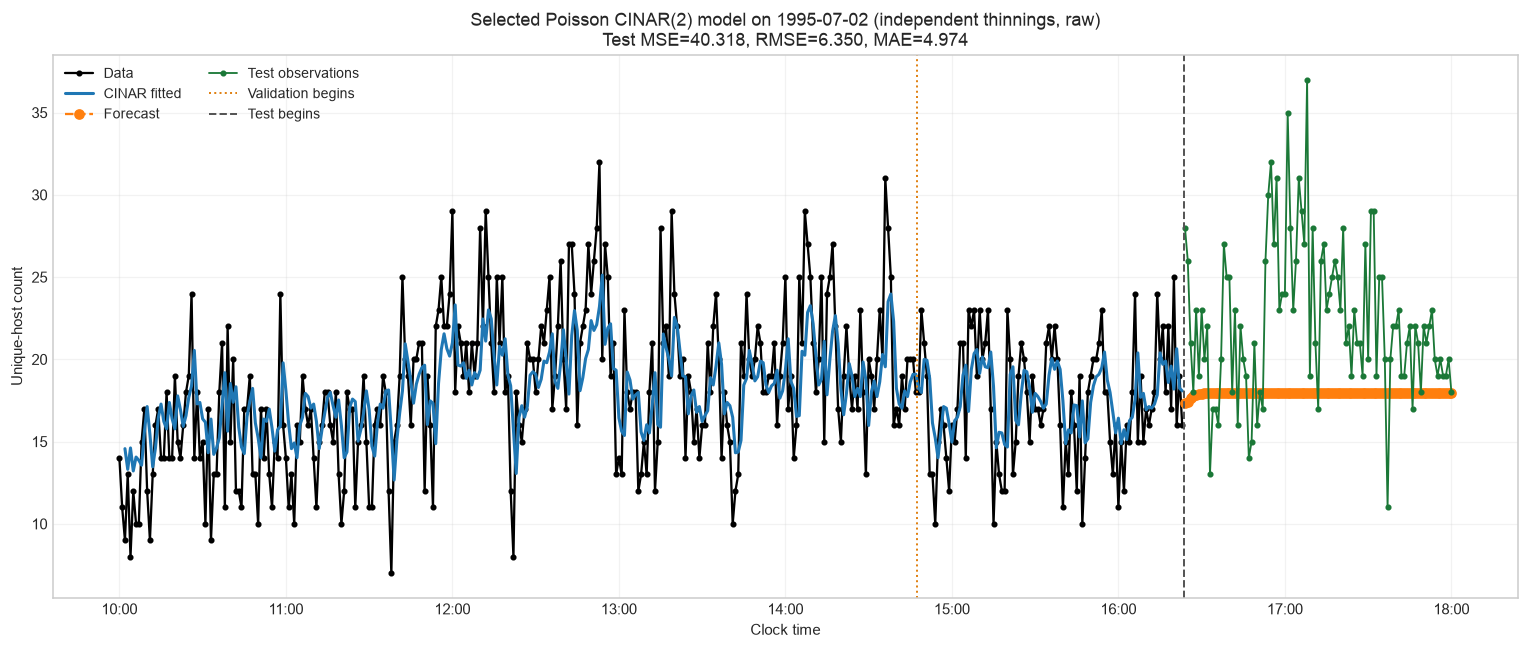

In [10]:
fig, ax = final_model.plot(development, n_steps=len(test))
test_time = np.arange(validation_end, len(counts))
ax.plot(
    test_time,
    test,
    color="#1b7837",
    marker="o",
    markersize=3,
    linewidth=1.2,
    label="Test observations",
)
ax.axvline(train_end - 0.5, color="#e08214", linestyle=":", linewidth=1.3, label="Validation begins")
ax.axvline(validation_end - 0.5, color="#555555", linestyle="--", linewidth=1.3, label="Test begins")
tick_positions = np.linspace(0, len(counts) - 1, 9, dtype=int)
tick_labels = day_data.loc[tick_positions, "minute"].dt.strftime("%H:%M")
ax.set_xticks(tick_positions, tick_labels)
ax.set(
    title=(
        f"Selected Poisson CINAR({best_p}) model on {CHOSEN_DATE} "
        f"({best_operator} thinnings, {DATASET_KIND})\n"
        f"Test MSE={test_scores['mse']:.3f}, RMSE={test_scores['rmse']:.3f}, MAE={test_scores['mae']:.3f}"
    ),
    xlabel="Clock time",
    ylabel="Unique-host count",
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, ncol=2, fontsize=9)
fig.set_size_inches(14, 6)
fig.tight_layout()
plt.show()

In [11]:
test_results = pd.DataFrame(
    {
        "minute": day_data.loc[validation_end:, "minute"].to_numpy(),
        "observed": test,
        "forecast": test_forecast,
        "error": test - test_forecast,
    }
)
test_results.head(12).style.format({"forecast": "{:.3f}", "error": "{:.3f}"})

,minute,observed,forecast,error
0,1995-07-02 16:24:00,28,17.334,10.666
1,1995-07-02 16:25:00,26,17.414,8.586
2,1995-07-02 16:26:00,21,17.649,3.351
3,1995-07-02 16:27:00,18,17.755,0.245
4,1995-07-02 16:28:00,23,17.834,5.166
5,1995-07-02 16:29:00,19,17.881,1.119
6,1995-07-02 16:30:00,23,17.912,5.088
7,1995-07-02 16:31:00,20,17.932,2.068
8,1995-07-02 16:32:00,22,17.944,4.056
9,1995-07-02 16:33:00,13,17.952,-4.952


## 6. Save and inspect the selected model

The selected specification is saved under `saved_models/<day>.json`. Parameters and fit statistics come from the final model refitted on the combined training and validation blocks. Split-specific metrics preserve the evaluation protocol: training metrics come from the train-only selected candidate, validation metrics come from its recursive validation forecast, and test metrics come from the final model's untouched recursive test forecast.

In [12]:
selected_training_model = candidate_models[(best_p, best_operator)]
train_scores = forecast_metrics(
    train[best_p:],
    selected_training_model.fitted_values_[best_p:],
)

train_metrics = {
    "observations": len(train) - best_p,
    "MSE": train_scores["mse"],
    "RMSE": train_scores["rmse"],
    "MAE": train_scores["mae"],
    "AIC": selected_training_model.aic_,
    "BIC": selected_training_model.bic_,
}
validation_metrics = {
    "observations": len(validation),
    "MSE": float(best["validation_MSE"]),
    "RMSE": float(best["validation_RMSE"]),
    "MAE": float(best["validation_MAE"]),
}
test_metrics = {
    "observations": len(test),
    "MSE": test_scores["mse"],
    "RMSE": test_scores["rmse"],
    "MAE": test_scores["mae"],
}

saved_model_path = final_model.save_model(
    day=CHOSEN_DATE,
    train_metrics=train_metrics,
    validation_metrics=validation_metrics,
    test_metrics=test_metrics,
    repository=PROJECT_DIR / "saved_models",
)
print(f"Saved selected model to: {saved_model_path.resolve()}")

Saved selected model to: /Users/andja/Projects/projekti_doktorske/nasa/saved_models/1995-07-02.json


In [13]:
with saved_model_path.open("r", encoding="utf-8") as stream:
    saved_model = json.load(stream)

print(json.dumps(saved_model, indent=2))

{
  "schema_version": 1,
  "day": "1995-07-02",
  "model": {
    "class": "PoissonCINARp",
    "p": 2,
    "thinning_operator": "independent"
  },
  "parameters": {
    "alpha": 0.5529354678561944,
    "innovation_mean": 8.032135469372324,
    "marginal_mean": 17.966389395409827,
    "phi": [
      0.7256523912859634,
      0.2743476087140367
    ]
  },
  "fit_statistics": {
    "log_likelihood": -1044.5146297398444,
    "AIC": 2095.029259479689,
    "BIC": 2106.8655213055085,
    "MSE": 13.86922029365485
  },
  "evaluation_metrics": {
    "train": {
      "observations": 286,
      "MSE": 14.84728005516159,
      "RMSE": 3.853216845073943,
      "MAE": 3.035670578405488,
      "AIC": 1590.5366204554557,
      "BIC": 1601.5045958879152
    },
    "validation": {
      "observations": 96,
      "MSE": 13.670030210171289,
      "RMSE": 3.6973003949058953,
      "MAE": 3.063018051403869
    },
    "test": {
      "observations": 97,
      "MSE": 40.317954738005405,
      "RMSE": 6.3496420